# NER — ViSoBERT Token Classification (v2)

Single unified model for all 13 entity types.
- Data: per-file 70/15/15 split + augmented weak-class samples
- Imbalance: no-entity product_ner downsampled to ≤35%
- Loss: Focal Loss (γ=2) — focuses on hard/rare examples

**Tuning (anti-overfit + precision):** epochs 100→40 (LR schedule decays), freeze embeddings + first 4 encoder layers, weight_decay 0.01→0.05, class weights capped at 15× with O raised to 0.20 (previous run was P=0.56 / R=0.76 — over-predicting entities).

In [1]:
!pip install transformers torch seqeval scikit-learn hf_xet --quiet

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
import json, os, random
import numpy as np
import torch
import torch.nn as nn
from collections import Counter
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    get_linear_schedule_with_warmup,
)
from seqeval.metrics import classification_report, f1_score as seqeval_f1
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME   = 'uitnlp/visobert'
MAX_LENGTH   = 128
BATCH_SIZE   = 16
LR           = 2e-5
EPOCHS       = 50        # 100→40→50: best was at epoch 39/40 (hit max, not early-stop) → more runway
PATIENCE     = 8
WARMUP_RATIO = 0.1
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

os.makedirs('results', exist_ok=True)

c:\Users\Huawei\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [4]:
# 13 entity types → 27 classes (O + B/I × 13)
ENTITY_TYPES = [
    'NAME', 'PHONE', 'ADDRESS', 'CITY',
    'PRODUCT_NAME', 'SHIP_DATE', 'SHIP_TIME', 'TYPE',
    'COMPLEXITY', 'QUANTITY', 'PRODUCT_COLOR',
    'MAX_BUDGET', 'MIN_BUDGET',
]
LABELS   = ['O'] + [f'{p}-{e}' for e in ENTITY_TYPES for p in ('B', 'I')]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for i, l in enumerate(LABELS)}
NUM_LABELS = len(LABELS)
print(f'Total labels: {NUM_LABELS}')
print(LABELS)

Total labels: 27
['O', 'B-NAME', 'I-NAME', 'B-PHONE', 'I-PHONE', 'B-ADDRESS', 'I-ADDRESS', 'B-CITY', 'I-CITY', 'B-PRODUCT_NAME', 'I-PRODUCT_NAME', 'B-SHIP_DATE', 'I-SHIP_DATE', 'B-SHIP_TIME', 'I-SHIP_TIME', 'B-TYPE', 'I-TYPE', 'B-COMPLEXITY', 'I-COMPLEXITY', 'B-QUANTITY', 'I-QUANTITY', 'B-PRODUCT_COLOR', 'I-PRODUCT_COLOR', 'B-MAX_BUDGET', 'I-MAX_BUDGET', 'B-MIN_BUDGET', 'I-MIN_BUDGET']


## 1. Data Loading — per-file split (Option B)

Split each source file independently at 70/15/15, then merge the three train sets,
three val sets, and three test sets. This ensures each entity type appears in all splits.

In [5]:
DATA_DIR = Path('../ner_data')

def split_file(records, train_r=0.70, val_r=0.15, seed=SEED):
    idx = list(range(len(records)))
    random.Random(seed).shuffle(idx)
    n_tr = int(len(records) * train_r)
    n_va = int(len(records) * val_r)
    return (
        [records[i] for i in idx[:n_tr]],
        [records[i] for i in idx[n_tr:n_tr + n_va]],
        [records[i] for i in idx[n_tr + n_va:]],
    )

def load_json(path):
    return json.loads(Path(path).read_text(encoding='utf-8'))

def downsample_no_entity(records, max_ratio=0.35, seed=SEED):
    """Keep all entity samples; downsample no-entity to at most max_ratio of total."""
    with_ent = [r for r in records if r['entities']]
    no_ent   = [r for r in records if not r['entities']]
    max_keep = int(len(with_ent) * max_ratio / (1 - max_ratio))
    kept     = random.Random(seed).sample(no_ent, min(len(no_ent), max_keep))
    return with_ent + kept

# ── Load base files ────────────────────────────────────────────────────────────
product_records = load_json(DATA_DIR / 'product_ner.json')
info_records    = load_json(DATA_DIR / 'info_ner.json')
budget_records  = load_json(DATA_DIR / 'budget_ner.json')

# ── Load augmented files if they exist ────────────────────────────────────────
for aug_path, target in [
    (DATA_DIR / 'augmented_product_ner.json', 'product'),
    (DATA_DIR / 'augmented_info_ner.json',    'info'),
    (DATA_DIR / 'augmented_budget_ner.json',  'budget'),
]:
    if aug_path.exists():
        aug = load_json(aug_path)
        if target == 'product':
            product_records += aug
        elif target == 'info':
            info_records += aug
        elif target == 'budget':
            budget_records += aug
        print(f'Loaded {len(aug)} augmented {target}_ner samples')

# ── Downsample no-entity product_ner (was 52% → ≤35%) ─────────────────────────
before = len(product_records)
product_records = downsample_no_entity(product_records)
no_ent_pct = sum(1 for r in product_records if not r['entities']) / len(product_records) * 100
print(f'product_ner: {before} → {len(product_records)} after downsampling ({no_ent_pct:.0f}% no-entity)')

# ── Per-file split then merge ──────────────────────────────────────────────────
all_train, all_val, all_test = [], [], []
for fname, records in [('info_ner', info_records),
                        ('product_ner', product_records),
                        ('budget_ner', budget_records)]:
    tr, va, te = split_file(records)
    all_train += tr
    all_val   += va
    all_test  += te
    print(f'{fname}: {len(records):>4} total  →  {len(tr):>4} train / {len(va):>3} val / {len(te):>3} test')

random.shuffle(all_train)
print(f'\nCombined: {len(all_train)} train / {len(all_val)} val / {len(all_test)} test')

Loaded 415 augmented product_ner samples
Loaded 50 augmented info_ner samples
Loaded 80 augmented budget_ner samples
product_ner: 2243 → 1978 after downsampling (35% no-entity)
info_ner:  243 total  →   170 train /  36 val /  37 test
product_ner: 1978 total  →  1384 train / 296 val / 298 test
budget_ner:  204 total  →   142 train /  30 val /  32 test

Combined: 1696 train / 362 val / 367 test


## 2. Tokenisation + BIO Alignment

Character-level spans (start, end) are mapped to subword token labels.
Only the **first subword** of each word receives a label — continuation subwords
get `-100` and are ignored by the loss.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align(record):
    text     = record['text']
    entities = sorted(record.get('entities', []), key=lambda e: e['start'])

    enc = tokenizer(
        text,
        max_length=MAX_LENGTH,
        truncation=True,
        padding=False,
        return_offsets_mapping=True,
    )
    offset_mapping = enc['offset_mapping']
    word_ids       = enc.word_ids()

    labels, prev_word_id = [], None
    for offset, wid in zip(offset_mapping, word_ids):
        if wid is None:                  # [CLS] / [SEP]
            labels.append(-100)
        elif wid == prev_word_id:        # continuation subword
            labels.append(-100)
        else:
            tok_s, tok_e = offset
            tag = 'O'
            for ent in entities:
                if tok_s >= ent['start'] and tok_e <= ent['end']:
                    prefix = 'B' if tok_s == ent['start'] else 'I'
                    tag    = f"{prefix}-{ent['label']}"
                    break
            labels.append(label2id.get(tag, label2id['O']))
        prev_word_id = wid

    return {
        'input_ids'     : enc['input_ids'],
        'attention_mask': enc['attention_mask'],
        'labels'        : labels,
    }

In [7]:
# Smoke test — show FULL words (not just the first sub-token) so the BIO labels are
# easy to read. ViSoBERT's SentencePiece tokenizer splits each word into several
# sub-tokens; only the FIRST sub-token of a word carries the label (the rest are -100).
sample_rec = next(r for r in all_train if r['entities'])
text     = sample_rec['text']
enc      = tokenizer(text, max_length=MAX_LENGTH, truncation=True, return_offsets_mapping=True)
toks     = tokenizer.convert_ids_to_tokens(enc['input_ids'])
offsets  = enc['offset_mapping']
word_ids = enc.word_ids()
labels   = tokenize_and_align(sample_rec)['labels']

# Full char span of each word: first sub-token start … last sub-token end
word_span = {}
for (s, e), wid in zip(offsets, word_ids):
    if wid is None:
        continue
    if wid not in word_span:
        word_span[wid] = [s, e]
    else:
        word_span[wid][1] = e

print(f'Text: {text!r}\n')
print(f'{"Word":<14}{"1st sub-token":<16}Label')
for tok, (s, e), wid, lab in zip(toks, offsets, word_ids, labels):
    if lab == -100:                 # skip continuation sub-tokens & [CLS]/[SEP]
        continue
    ws, we = word_span[wid]
    print(f'  {text[ws:we]:<14}{tok:<16}{id2label[lab]}')

Text: 'Còn bộ Porsche 911 màu xanh lá cây ko shop?'

Word          1st sub-token   Label
  Còn           ▁C              O
  bộ            ▁bộ             O
  Porsche       ▁P              B-PRODUCT_NAME
  911           ▁9              I-PRODUCT_NAME
  màu           ▁màu            O
  xanh          ▁x              B-PRODUCT_COLOR
  lá            ▁lá             I-PRODUCT_COLOR
  cây           ▁c              I-PRODUCT_COLOR
  ko            ▁ko             O
  shop?         ▁shop           O


## 3. Dataset + DataLoader

In [8]:
def maybe_lowercase(record, p=0.3):
    """Randomly lowercase the text of a record (30% chance per call).

    .lower() preserves character count for Vietnamese, so char offsets stay valid.
    """
    if random.random() < p:
        return {**record, 'text': record['text'].lower()}
    return record

class NERDataset(Dataset):
    def __init__(self, records, augment=False):
        self.records = records
        self.augment = augment   # True only for train split
    def __len__(self):
        return len(self.records)
    def __getitem__(self, idx):
        rec = self.records[idx]
        if self.augment:
            rec = maybe_lowercase(rec)   # fresh roll each epoch → variation across epochs
        return tokenize_and_align(rec)

def collate_fn(batch):
    max_len = max(len(s['input_ids']) for s in batch)
    input_ids, masks, labels = [], [], []
    for s in batch:
        pad = max_len - len(s['input_ids'])
        input_ids.append(s['input_ids'] + [tokenizer.pad_token_id] * pad)
        masks.append(s['attention_mask'] + [0] * pad)
        labels.append(s['labels'] + [-100] * pad)
    return {
        'input_ids'     : torch.tensor(input_ids),
        'attention_mask': torch.tensor(masks),
        'labels'        : torch.tensor(labels),
    }

train_ds = NERDataset(all_train, augment=True)    # random lowercase 30% per epoch
val_ds   = NERDataset(all_val,   augment=False)   # original text — clean eval
test_ds  = NERDataset(all_test,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
print(f'Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}')
print(f'Case augmentation: ON (p=0.30) for train | OFF for val/test')

Batches — train: 106, val: 23, test: 23
Case augmentation: ON (p=0.30) for train | OFF for val/test


## 4. Class Weights

`O` dominates (most tokens are outside any entity). Weighted CrossEntropy
downweights `O` so the model is penalised more for missing real entities.

In [9]:
label_counts = Counter()
for rec in all_train:
    for lab in tokenize_and_align(rec)['labels']:
        if lab != -100:
            label_counts[lab] += 1

total   = sum(label_counts.values())
weights = torch.ones(NUM_LABELS)
for lab_id, cnt in label_counts.items():
    weights[lab_id] = total / (NUM_LABELS * cnt)

# Tame the extremes. Raw inverse-frequency gave e.g. I-PHONE ~152x, which destabilises
# training (loss spikes at epochs 52-55) and pushes the model to over-predict entities
# → low precision (test P=0.56 vs R=0.76). Cap the entity weights, and RAISE the O weight
# so false-positive entities cost more → trades a little recall for precision.
WEIGHT_CAP = 15.0
weights = torch.clamp(weights, max=WEIGHT_CAP)

O_IDX = label2id['O']
weights[O_IDX] = 0.20            # was 0.0518 — higher O weight = more conservative = better precision
weights = weights.to(DEVICE)

print(f'O tag weight : {weights[O_IDX].item():.4f}  (cap on entities: {WEIGHT_CAP}x)')
print('Top-5 highest weights:')
for i in sorted(range(NUM_LABELS), key=lambda i: -weights[i].item())[:5]:
    print(f'  {LABELS[i]:<25} {weights[i].item():.3f}')

O tag weight : 0.2000  (cap on entities: 15.0x)
Top-5 highest weights:
  I-PHONE                   15.000
  B-CITY                    15.000
  I-CITY                    15.000
  I-MIN_BUDGET              15.000
  I-PRODUCT_COLOR           8.716


## 5. Model Setup

In [10]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    """Focal Loss — down-weights easy/frequent examples, focuses on hard/rare ones.
    γ=2 is the standard default; higher γ = more focus on hard examples.
    """
    def __init__(self, weight=None, gamma=2.0, ignore_index=-100):
        super().__init__()
        self.weight       = weight
        self.gamma        = gamma
        self.ignore_index = ignore_index

    def forward(self, logits, targets):
        ce   = F.cross_entropy(logits, targets, weight=self.weight,
                               ignore_index=self.ignore_index, reduction='none')
        pt   = torch.exp(-ce)                       # predicted probability of correct class
        loss = ((1 - pt) ** self.gamma) * ce        # down-weight easy examples
        mask = targets != self.ignore_index
        return loss[mask].mean()


model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)
model.to(DEVICE)

# Freeze embeddings + the lowest encoder layers to curb memorization (train loss was
# collapsing to ~0.002 while val F1 plateaued). Lower layers already encode generic
# Vietnamese syntax from pre-training; only upper layers + the head need to adapt.
FREEZE_LAYERS = 4                       # of XLM-R base's 12 encoder layers
base = model.base_model
for p in base.embeddings.parameters():
    p.requires_grad = False
for layer in base.encoder.layer[:FREEZE_LAYERS]:
    for p in layer.parameters():
        p.requires_grad = False
trainable = [p for p in model.parameters() if p.requires_grad]

optimizer    = torch.optim.AdamW(trainable, lr=LR, weight_decay=0.05)   # wd 0.01 → 0.05
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
criterion    = FocalLoss(weight=weights, gamma=2.0, ignore_index=-100)

n_train = sum(p.numel() for p in trainable)
n_total = sum(p.numel() for p in model.parameters())
print(f'Frozen     : embeddings + first {FREEZE_LAYERS} layers')
print(f'Trainable  : {n_train:,} / {n_total:,} ({100*n_train/n_total:.0f}%)')
print(f'Train steps: {total_steps}  |  Warmup: {warmup_steps}')
print(f'Loss       : FocalLoss (γ=2.0) + class weights | weight_decay=0.05')

Loading weights: 100%|██████████| 197/197 [00:00<?, ?it/s]
[transformers] XLMRobertaForTokenClassification LOAD REPORT from: uitnlp/visobert
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
classifier.weight         | MISSING    | 
classifier.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Frozen     : embeddings + first 4 layers
Trainable  : 56,723,739 / 96,996,123 (58%)
Train steps: 5300  |  Warmup: 530
Loss       : FocalLoss (γ=2.0) + class weights | weight_decay=0.05


## 6. Training

In [11]:
def predict_tags(loader):
    """Return (all_preds, all_trues) as lists of tag-string sequences."""
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for batch in loader:
            logits = model(
                input_ids      = batch['input_ids'].to(DEVICE),
                attention_mask = batch['attention_mask'].to(DEVICE),
            ).logits
            preds  = logits.argmax(-1).cpu()
            labels = batch['labels']
            for pred_row, true_row in zip(preds, labels):
                p_seq, t_seq = [], []
                for p, t in zip(pred_row.tolist(), true_row.tolist()):
                    if t != -100:
                        p_seq.append(id2label[p])
                        t_seq.append(id2label[t])
                all_preds.append(p_seq)
                all_trues.append(t_seq)
    return all_preds, all_trues

def evaluate_f1(loader):
    preds, trues = predict_tags(loader)
    return seqeval_f1(trues, preds, average='micro', zero_division=0)

In [12]:
train_losses, val_f1s = [], []
best_val_f1, best_epoch, patience_ctr = 0.0, 0, 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        logits = model(
            input_ids      = batch['input_ids'].to(DEVICE),
            attention_mask = batch['attention_mask'].to(DEVICE),
        ).logits
        loss = criterion(logits.view(-1, NUM_LABELS), batch['labels'].to(DEVICE).view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    val_f1   = evaluate_f1(val_loader)
    train_losses.append(avg_loss)
    val_f1s.append(val_f1)

    improved = val_f1 > best_val_f1
    if improved:
        best_val_f1, best_epoch, patience_ctr = val_f1, epoch, 0
        torch.save(model.state_dict(), 'results/ner_best_model.pt')
    else:
        patience_ctr += 1

    flag = ' *' if improved else ''
    print(f'Epoch {epoch:>2}/{EPOCHS} | Loss: {avg_loss:.4f} | Val Micro-F1: {val_f1:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch} (best: epoch {best_epoch})')
        break

print(f'\nBest Val Micro-F1: {best_val_f1:.4f} at epoch {best_epoch}')

Epoch  1/50 | Loss: 2.9579 | Val Micro-F1: 0.0222 *
Epoch  2/50 | Loss: 2.2018 | Val Micro-F1: 0.1479 *
Epoch  3/50 | Loss: 1.1303 | Val Micro-F1: 0.2295 *
Epoch  4/50 | Loss: 0.5240 | Val Micro-F1: 0.2899 *
Epoch  5/50 | Loss: 0.2801 | Val Micro-F1: 0.3481 *
Epoch  6/50 | Loss: 0.1575 | Val Micro-F1: 0.4101 *
Epoch  7/50 | Loss: 0.0895 | Val Micro-F1: 0.5174 *
Epoch  8/50 | Loss: 0.0531 | Val Micro-F1: 0.5050
Epoch  9/50 | Loss: 0.0323 | Val Micro-F1: 0.5320 *
Epoch 10/50 | Loss: 0.0339 | Val Micro-F1: 0.5770 *
Epoch 11/50 | Loss: 0.0271 | Val Micro-F1: 0.6027 *
Epoch 12/50 | Loss: 0.0173 | Val Micro-F1: 0.6160 *
Epoch 13/50 | Loss: 0.0153 | Val Micro-F1: 0.6103
Epoch 14/50 | Loss: 0.0135 | Val Micro-F1: 0.6578 *
Epoch 15/50 | Loss: 0.0106 | Val Micro-F1: 0.6351
Epoch 16/50 | Loss: 0.0092 | Val Micro-F1: 0.6862 *
Epoch 17/50 | Loss: 0.0086 | Val Micro-F1: 0.6909 *
Epoch 18/50 | Loss: 0.0077 | Val Micro-F1: 0.6856
Epoch 19/50 | Loss: 0.0086 | Val Micro-F1: 0.6963 *
Epoch 20/50 | Loss: 

## 7. Training Curves

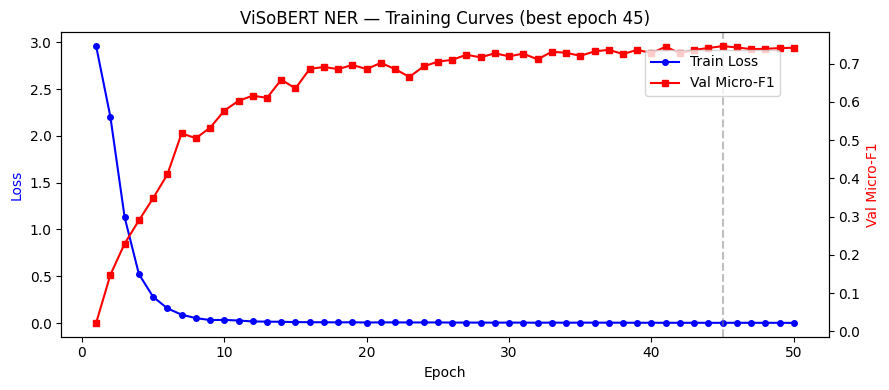

In [13]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2      = ax1.twinx()
epochs_x = list(range(1, len(train_losses) + 1))

ax1.plot(epochs_x, train_losses, 'b-o', markersize=4, label='Train Loss')
ax2.plot(epochs_x, val_f1s,     'r-s', markersize=4, label='Val Micro-F1')
ax1.axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss',        color='b')
ax2.set_ylabel('Val Micro-F1', color='r')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.title(f'ViSoBERT NER — Training Curves (best epoch {best_epoch})')
plt.tight_layout()
plt.savefig('results/ner_training_curves.png', dpi=150)
plt.show()

## 8. Test Evaluation (entity-level F1 via seqeval)

In [14]:
model.load_state_dict(torch.load('results/ner_best_model.pt', map_location=DEVICE))
test_preds, test_trues = predict_tags(test_loader)

report = classification_report(test_trues, test_preds, digits=4, zero_division=0)
print(report)

with open('results/ner_test_report.txt', 'w', encoding='utf-8') as f:
    f.write(report)

               precision    recall  f1-score   support

      ADDRESS     0.8065    0.8929    0.8475        28
         CITY     0.6667    0.8000    0.7273         5
   COMPLEXITY     0.4038    0.5526    0.4667        38
   MAX_BUDGET     0.9310    0.9643    0.9474        28
   MIN_BUDGET     0.8421    1.0000    0.9143        16
         NAME     0.8846    0.9583    0.9200        24
        PHONE     1.0000    1.0000    1.0000        26
PRODUCT_COLOR     0.5333    0.7273    0.6154        11
 PRODUCT_NAME     0.6348    0.7300    0.6791       100
     QUANTITY     0.8182    1.0000    0.9000         9
    SHIP_DATE     0.5333    0.6857    0.6000        35
    SHIP_TIME     0.6977    0.8571    0.7692        35
         TYPE     0.4000    0.6087    0.4828        23

    micro avg     0.6623    0.7937    0.7220       378
    macro avg     0.7040    0.8290    0.7592       378
 weighted avg     0.6800    0.7937    0.7305       378



## 9. Save Model

In [15]:
os.makedirs('results/ner_model', exist_ok=True)
model.save_pretrained('results/ner_model')
tokenizer.save_pretrained('results/ner_model')
print('Saved to results/ner_model/')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.80it/s]

Saved to results/ner_model/


## 10. Inference Demo

In [16]:
def predict_ner(text: str) -> list[dict]:
    """Run NER inference.

    Aggregates sub-words to words: only the FIRST sub-word of each word carries the
    tag (exactly as during training, where continuation sub-words are -100). Reading
    every sub-word's prediction — as the old version did — fragments entities, because
    continuation sub-words were never trained and predict garbage.
    """
    model.eval()
    enc = tokenizer(
        text, max_length=MAX_LENGTH, truncation=True,
        return_offsets_mapping=True, return_tensors='pt',
    )
    offsets  = enc['offset_mapping'][0].tolist()
    word_ids = enc.word_ids(batch_index=0)
    inputs   = {k: v.to(DEVICE) for k, v in enc.items() if k != 'offset_mapping'}

    with torch.no_grad():
        preds = model(**inputs).logits[0].argmax(-1).tolist()

    # ── Sub-word → word: keep the first sub-word's tag, grow the span over continuations
    words, prev_wid = [], None      # each entry: [tag, start_char, end_char]
    for pred, (s, e), wid in zip(preds, offsets, word_ids):
        if wid is None:             # [CLS] / [SEP]
            continue
        if wid != prev_wid:         # first sub-word of a new word
            words.append([id2label[pred], s, e])
        else:                       # continuation sub-word → only extend the span
            words[-1][2] = e
        prev_wid = wid

    # ── BIO chunking at the WORD level
    entities, cur = [], None
    for tag, s, e in words:
        if tag == 'O':
            if cur:
                entities.append(cur); cur = None
        elif tag.startswith('B-'):
            if cur:
                entities.append(cur)
            cur = {'label': tag[2:], 'start': s, 'end': e}
        else:                       # I-XXX
            etype = tag[2:]
            if cur and cur['label'] == etype:
                cur['end'] = e
            else:                   # I- without a matching B- → start a fresh entity
                if cur:
                    entities.append(cur)
                cur = {'label': etype, 'start': s, 'end': e}
    if cur:
        entities.append(cur)

    for ent in entities:
        ent['text'] = text[ent['start']:ent['end']]
    return entities

In [17]:
test_cases = [
    'Nguyên Thảo\n0912495077\nK45/10B Dũng Sĩ Thanh Khê',
    'bạn có bộ nào tầm 200k không ạ',
    'mình muốn đặt bộ lego city, ship ngày mai nhé',
    'tên: Phạm Thành\nsdt: 0949913458\ndchi: 46 Sơn Hải Đồ Sơn Hải Phòng',
    'em ở hn ạ',
    'cho em đặt 1 bộ mẹc f1 về Cát Linh với ạ'
]
for text in test_cases:
    ents = predict_ner(text)
    print(f'Input : {text!r}')
    if ents:
        for e in ents:
            print(f'  {e["label"]:<15} {e["text"]!r}')
    else:
        print('  (no entities)')
    print()

Input : 'Nguyên Thảo\n0912495077\nK45/10B Dũng Sĩ Thanh Khê'
  NAME            'Nguyên Thảo'
  PHONE           '0912495077'
  ADDRESS         'K45/10B Dũng Sĩ Thanh Khê'

Input : 'bạn có bộ nào tầm 200k không ạ'
  COMPLEXITY      'tầm'
  MIN_BUDGET      '200k'

Input : 'mình muốn đặt bộ lego city, ship ngày mai nhé'
  SHIP_DATE       'ngày mai'

Input : 'tên: Phạm Thành\nsdt: 0949913458\ndchi: 46 Sơn Hải Đồ Sơn Hải Phòng'
  NAME            'Phạm Thành'
  PHONE           '0949913458'
  ADDRESS         '46 Sơn Hải Đồ Sơn Hải Phòng'

Input : 'em ở hn ạ'
  CITY            'hn'

Input : 'cho em đặt 1 bộ mẹc f1 về Cát Linh với ạ'
  QUANTITY        '1 bộ'
  PRODUCT_NAME    'mẹc f1 về Cát Linh'



In [18]:
import torch

def extract_entities_from_text(text, model, tokenizer, id2label, device='cuda'):
    """Same first-sub-word aggregation as predict_ner, but returns a {type: [values]}
    dict (deduplicated) for easy downstream use. A new B- always starts a new chunk,
    so two adjacent entities of the same type are not merged."""
    model.eval()

    enc = tokenizer(
        text, return_offsets_mapping=True, truncation=True,
        max_length=128, return_tensors='pt',
    )
    offsets  = enc['offset_mapping'][0].tolist()
    word_ids = enc.word_ids(batch_index=0)
    inputs   = {k: v.to(device) for k, v in enc.items() if k != 'offset_mapping'}

    with torch.no_grad():
        preds = model(**inputs).logits.argmax(-1)[0].cpu().tolist()

    # Sub-word → word: first sub-word carries the tag; continuations only extend the span
    words, prev_wid = [], None
    for pred, (s, e), wid in zip(preds, offsets, word_ids):
        if wid is None:
            continue
        if wid != prev_wid:
            words.append([id2label[pred], s, e])
        else:
            words[-1][2] = e
        prev_wid = wid

    # BIO chunking at the word level (respect B-/I- boundaries)
    chunks, cur = [], None
    for tag, s, e in words:
        if tag == 'O':
            if cur:
                chunks.append(cur); cur = None
            continue
        prefix, etype = tag.split('-', 1)
        if prefix == 'B' or cur is None or cur['type'] != etype:
            if cur:
                chunks.append(cur)
            cur = {'type': etype, 'start': s, 'end': e}
        else:                                  # I- continuing the same type
            cur['end'] = e
    if cur:
        chunks.append(cur)

    # Map spans back to text, clean stray punctuation, group + dedup by type
    final_results = {}
    for c in chunks:
        value = text[c['start']:c['end']].strip().lstrip(':').strip()
        if not value:
            continue
        final_results.setdefault(c['type'], [])
        if value not in final_results[c['type']]:
            final_results[c['type']].append(value)

    return final_results

In [19]:
test_input = 'có bộ nào cho bé nam tầm 2-300k không shop'

entities = extract_entities_from_text(
    text=test_input,
    model=model,
    tokenizer=tokenizer,
    id2label=id2label,
    device=DEVICE
)

for entity_type, values in entities.items():
    for val in values:
        print(f"{entity_type:<15} '{val}'")

MIN_BUDGET      '2-300k'


In [20]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tokenizer = AutoTokenizer.from_pretrained('uitnlp/visobert')          # từ HF Hub
model     = AutoModelForTokenClassification.from_pretrained('results/ner_model')  # local weights
model.to(DEVICE)
model.eval()

id2label = model.config.id2label


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8000.25it/s]
